# Black-Scholes from Scratch

A first-principles derivation and implementation of the Black-Scholes-Merton option pricing model — no `py_vollib`, no black-box pricing libraries. The only imports are `numpy`, `scipy.stats.norm` (for the standard normal CDF), and `matplotlib` for plotting.

**Goal:** derive the model from the underlying stochastic process, arrive at the closed-form pricing formula, implement it directly from the formula, and validate it against an independent Monte Carlo simulation.

---

## 1. Assumptions

We assume a risk-neutral world in which the underlying asset $S_t$ follows Geometric Brownian Motion (GBM):

$$
dS_t = r S_t\, dt + \sigma S_t\, dW_t
$$

where:
- $r$ — risk-free rate (constant)
- $\sigma$ — volatility (constant)
- $W_t$ — standard Brownian motion under the risk-neutral measure $\mathbb{Q}$

Further standard assumptions: no arbitrage, no transaction costs, continuous trading, the underlying pays no dividends, and borrowing/lending occurs at the risk-free rate.


## 2. From SDE to PDE — the hedging argument

Let $V(S,t)$ be the value of a derivative on $S$. Construct a portfolio $\Pi$ long one derivative and short $\Delta$ units of the underlying:

$$
\Pi = V - \Delta S
$$

By Itô's Lemma:

$$
dV = \left(\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \tfrac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S \frac{\partial V}{\partial S}\, dW_t
$$

Choosing $\Delta = \dfrac{\partial V}{\partial S}$ eliminates the stochastic term $dW_t$, making $\Pi$ instantaneously riskless. A riskless portfolio must earn the risk-free rate, $d\Pi = r\Pi\, dt$. Substituting and simplifying yields the **Black-Scholes PDE**:

$$
\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \tfrac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} - rV = 0
$$

subject to the terminal condition $V(S,T) = \max(S-K, 0)$ for a European call.


## 3. Solving the PDE — closed-form price

Solving this PDE (via a change of variables that reduces it to the heat equation, or equivalently via risk-neutral expectation $V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\max(S_T-K,0)]$ with $S_T$ log-normal under $\mathbb{Q}$) gives the closed-form **Black-Scholes formula**:

$$
C(S,t) = S\,N(d_1) - K e^{-r\tau} N(d_2)
$$
$$
P(S,t) = K e^{-r\tau} N(-d_2) - S\,N(-d_1)
$$

where $\tau = T-t$ and:

$$
d_1 = \frac{\ln(S/K) + \left(r + \tfrac{1}{2}\sigma^2\right)\tau}{\sigma\sqrt{\tau}}, \qquad d_2 = d_1 - \sigma\sqrt{\tau}
$$

$N(\cdot)$ is the standard normal CDF. Put-call parity, $C - P = S - Ke^{-r\tau}$, follows directly and gives us a consistency check later.


In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def d1_d2(S, K, r, sigma, tau):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return d1, d2

def bs_price(S, K, r, sigma, tau, option="call"):
    '''Closed-form Black-Scholes price for a European call or put.'''
    d1, d2 = d1_d2(S, K, r, sigma, tau)
    if option == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    elif option == "put":
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option must be 'call' or 'put'")


In [2]:
# Sanity check: put-call parity  C - P = S - K e^{-r tau}
S, K, r, sigma, tau = 100, 100, 0.05, 0.20, 1.0

C = bs_price(S, K, r, sigma, tau, "call")
P = bs_price(S, K, r, sigma, tau, "put")
parity_lhs = C - P
parity_rhs = S - K * np.exp(-r * tau)

print(f"Call price:  {C:.4f}")
print(f"Put price:   {P:.4f}")
print(f"C - P        = {parity_lhs:.6f}")
print(f"S - K e^-rT  = {parity_rhs:.6f}")
print(f"Parity holds: {np.isclose(parity_lhs, parity_rhs)}")


Call price:  10.4506
Put price:   5.5735
C - P        = 4.877058
S - K e^-rT  = 4.877058
Parity holds: True


## 4. The Greeks — closed form

Differentiating $C(S,t)$ directly gives the sensitivities. These are derived, not numerically approximated:

$$
\Delta_{\text{call}} = N(d_1), \qquad \Delta_{\text{put}} = N(d_1) - 1
$$
$$
\Gamma = \frac{N'(d_1)}{S\sigma\sqrt{\tau}} \qquad \text{(same for calls and puts)}
$$
$$
\text{Vega} = S\,N'(d_1)\sqrt{\tau} \qquad \text{(same for calls and puts)}
$$
$$
\Theta_{\text{call}} = -\frac{S N'(d_1)\sigma}{2\sqrt{\tau}} - rKe^{-r\tau}N(d_2)
$$
$$
\rho_{\text{call}} = K\tau e^{-r\tau} N(d_2)
$$

where $N'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ is the standard normal PDF.


In [3]:
def bs_greeks(S, K, r, sigma, tau, option="call"):
    '''Closed-form Greeks for a European call or put.'''
    d1, d2 = d1_d2(S, K, r, sigma, tau)
    pdf_d1 = norm.pdf(d1)

    gamma = pdf_d1 / (S * sigma * np.sqrt(tau))
    vega = S * pdf_d1 * np.sqrt(tau)

    if option == "call":
        delta = norm.cdf(d1)
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(tau))
                 - r * K * np.exp(-r * tau) * norm.cdf(d2))
        rho = K * tau * np.exp(-r * tau) * norm.cdf(d2)
    elif option == "put":
        delta = norm.cdf(d1) - 1
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(tau))
                 + r * K * np.exp(-r * tau) * norm.cdf(-d2))
        rho = -K * tau * np.exp(-r * tau) * norm.cdf(-d2)
    else:
        raise ValueError("option must be 'call' or 'put'")

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

bs_greeks(S, K, r, sigma, tau, "call")


{'delta': np.float64(0.6368306511756191),
 'gamma': np.float64(0.018762017345846895),
 'vega': np.float64(37.52403469169379),
 'theta': np.float64(-6.414027546438197),
 'rho': np.float64(53.232481545376345)}

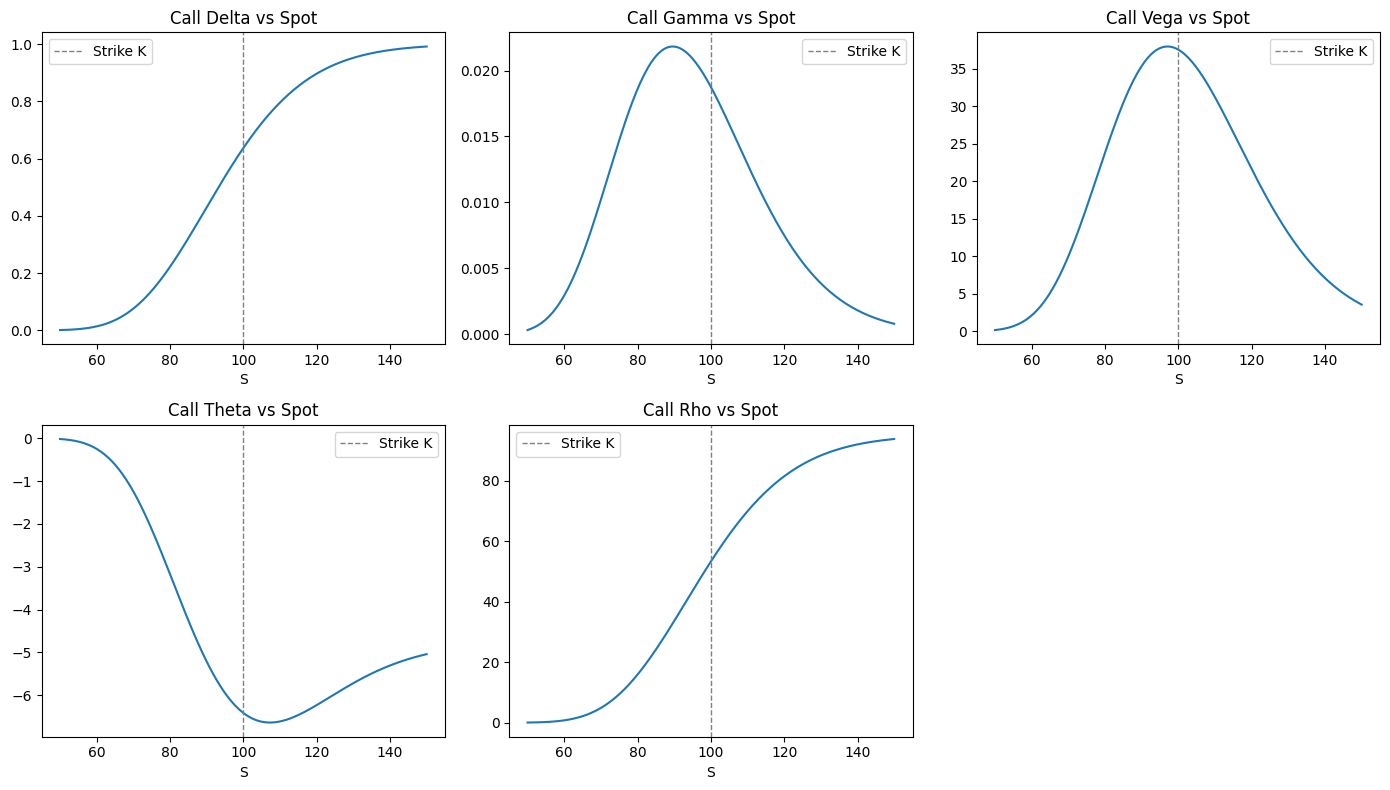

In [4]:
# All five Greeks as functions of spot -- classic shapes as sanity checks
spots = np.linspace(50, 150, 200)
greek_curves = {
    "Delta": [bs_greeks(s, K, r, sigma, tau, "call")["delta"] for s in spots],
    "Gamma": [bs_greeks(s, K, r, sigma, tau, "call")["gamma"] for s in spots],
    "Vega":  [bs_greeks(s, K, r, sigma, tau, "call")["vega"]  for s in spots],
    "Theta": [bs_greeks(s, K, r, sigma, tau, "call")["theta"] for s in spots],
    "Rho":   [bs_greeks(s, K, r, sigma, tau, "call")["rho"]   for s in spots],
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, (title, y) in zip(axes, greek_curves.items()):
    ax.plot(spots, y)
    ax.axvline(K, color="grey", linestyle="--", linewidth=1, label="Strike K")
    ax.set_title(f"Call {title} vs Spot")
    ax.set_xlabel("S")
    ax.legend()
axes[-1].axis("off")  # unused 6th subplot slot
plt.tight_layout()
plt.show()


**Reading the Greeks plots**

Two distinct shapes show up across the five panels, and the split is meaningful:

- **Delta and Rho — monotonic S-curves.** Both rise smoothly from ~0 (deep OTM, $S=50$) to their maximum (deep ITM, $S=150$). Deep OTM, the call is nearly worthless and barely reacts to the stock or to rates. Deep ITM, it behaves almost like the stock itself (delta $\to 1$) and like a leveraged forward position (rho at its highest), so both sensitivities are largest there.

- **Gamma and Vega — bumps peaking at the strike.** Both are highest near $S=K$ and decay toward 0 on either side. This is where the option's fate is most *uncertain* — it could plausibly finish either ITM or OTM — so a change in spot (gamma) or in volatility (vega) has the biggest effect on price there. Far from the strike, the outcome is already essentially decided, so these sensitivities collapse toward 0.

- **Theta — a trough, not a bump.** It's negative everywhere in this range and dips to its most negative point right at the strike, mirroring gamma and vega's peak. This makes sense together: the at-the-money option has the most time value at stake, so it also has the most to lose per day as that time value decays.

The common pattern: **directional sensitivities (Δ, ρ) are monotonic**, while **convexity/uncertainty sensitivities (Γ, Vega, Θ) peak at the money** — a useful sanity check to recognize when validating any option pricing implementation, not just this one.


## 5. Validation via Monte Carlo

As an independent check, simulate GBM paths under $\mathbb{Q}$ directly and price the option as the discounted expected payoff. Since $S_T$ under GBM is log-normal, we can sample $S_T$ exactly (no discretization error) via:

$$
S_T = S_0 \exp\left[\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right], \qquad Z \sim \mathcal{N}(0,1)
$$


In [5]:
def mc_price(S0, K, r, sigma, T, n_paths=1_000_000, option="call", seed=42):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_paths)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    discounted = np.exp(-r * T) * payoff
    price = discounted.mean()
    stderr = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, stderr

mc_call, se_call = mc_price(S, K, r, sigma, tau, n_paths=2_000_000, option="call")
closed_form_call = bs_price(S, K, r, sigma, tau, "call")

print(f"Closed-form call price: {closed_form_call:.4f}")
print(f"Monte Carlo call price: {mc_call:.4f}  (± {1.96*se_call:.4f}, 95% CI)")
print(f"Absolute error:         {abs(mc_call - closed_form_call):.5f}")


Closed-form call price: 10.4506
Monte Carlo call price: 10.4556  (± 0.0204, 95% CI)
Absolute error:         0.00500


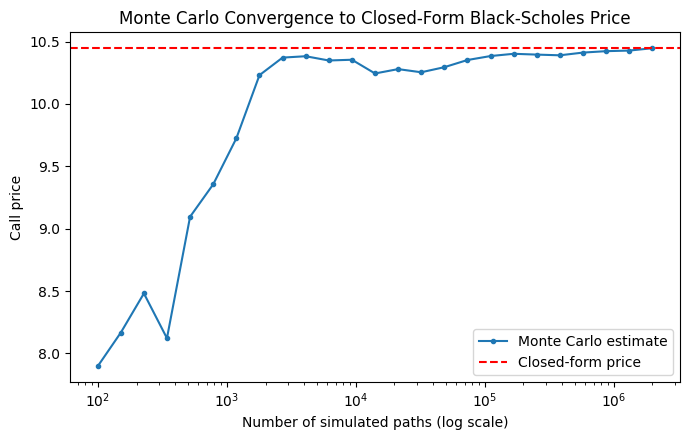

In [6]:
# Convergence: MC price vs. number of paths, against the closed-form benchmark
path_counts = np.unique(np.logspace(2, 6.3, 25).astype(int))
mc_estimates = [mc_price(S, K, r, sigma, tau, n_paths=n, option="call", seed=1)[0] for n in path_counts]

plt.figure(figsize=(7, 4.5))
plt.plot(path_counts, mc_estimates, marker="o", markersize=3, label="Monte Carlo estimate")
plt.axhline(closed_form_call, color="red", linestyle="--", label="Closed-form price")
plt.xscale("log")
plt.xlabel("Number of simulated paths (log scale)")
plt.ylabel("Call price")
plt.title("Monte Carlo Convergence to Closed-Form Black-Scholes Price")
plt.legend()
plt.tight_layout()
plt.show()


**Reading the convergence plot**

At small path counts (left side, $10^2$–$10^3$ paths), the blue Monte Carlo line swings noticeably around the red closed-form line — with only a few hundred simulated outcomes, the sample average is a noisy estimate of the true expectation. As the path count increases toward $10^5$–$10^6$ (right side), the swings shrink and the blue line settles tightly onto the red line.

This is the Law of Large Numbers visibly at work: Monte Carlo error shrinks proportionally to $1/\sqrt{n}$, so quadrupling the number of paths only halves the error — which is why the line keeps tightening but never perfectly flattens even at $2\times10^6$ paths. The fact that two *independent* methods — solving a PDE analytically vs. averaging simulated payoffs — converge to the same number is the real validation here: it's strong evidence the closed-form implementation is correct, not just internally consistent.


## 6. Summary

- Derived the Black-Scholes PDE from GBM via a delta-hedging, no-arbitrage argument.
- Solved the PDE (equivalently, computed the risk-neutral discounted expectation) to reach the closed-form pricing formula.
- Implemented pricing and Greeks directly from their closed-form expressions — no external pricing libraries.
- Validated the closed-form price against an independent Monte Carlo simulation, with convergence as path count grows and error consistent with the Monte Carlo standard error.

**Possible next steps:** relax constant volatility (local/stochastic vol), implied volatility inversion and the smile, American-style early exercise via PDE/finite differences or LSM, and eventually connecting this to AMM-based on-chain option protocols.
